In [39]:
import pandas as pd
import numpy as np

columns = ["index", "color", "trouble"]
df = pd.read_csv("datasets/unsupervised/Student_Dataset.csv", names=columns)

## Formatter le dataset pour qu'il n'y reste plus que les phrases des patients

In [40]:
df_clean = pd.DataFrame(columns=columns)

for line in df.itertuples(index=False):
    line = list(line)

    if np.nan in line:
        df_clean.loc[len(df_clean)] = [line[0], np.nan, line[1]]
    else:
        df_clean.loc[len(df_clean)] = line

df_clean = df_clean.drop(["index", "color"], axis=1)
df_clean.dropna(inplace=True)

In [41]:
SEED = 42

## Vectoriser les phrases des patients pour récupérer les mots-clés des phrases avec la méthode **TF-IDF**

- `stop_words` avec l'argument **english** sert à ne pas prendre en compte les mots de base d'une phrase qui ne sont pas intéressant (*a*, *the*, *he*, *I*, ...)
- `max_features` défini le nombre de mots-clés à sortir des phrases des patients
- `ngram_range=(x,y)` demande que les mots-clés fassent entre *x* et *y* mots

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=500,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df_clean["trouble"])

words = vectorizer.get_feature_names_out()

print(f"NOMBRE DE MOTS-CLÉS APRÈS LA VECTORISATION: {len(words)}")
print(f"FEATURE SHAPE: {X.shape}")

NOMBRE DE MOTS-CLÉS APRÈS LA VECTORISATION: 500
FEATURE SHAPE: (1011, 500)


## Regrouper les mots-clés en **clusters** avec le modèle **KMeans**

- `n_clusters` spécifie le nombre de clusters à avoir

>On ajoute une colonne *cluster* qui correspond au numéro du cluster auquel la phrase appartient

In [43]:
from sklearn.cluster import KMeans

nb_clusters = 8

kmeans = KMeans(
    n_clusters=nb_clusters,
    random_state=SEED
)

df_clean["cluster"] = kmeans.fit_predict(X)

#### Affichage des `nb_frequent_words` mots-clés les plus fréquents dans chaques clusters (les mots-clés qui ont le plus gros poid)

In [44]:
# FAIRE UN GRAPH DE MOTS AVEC LES LISTES DE MOTS PAR CLUSTERS

print("\nMOTS LES PLUS FRÉQUENTS DANS LES CLUSTERS :\n")

clusters_frequent_words = {}

nb_frequent_words = 5

for i in range(nb_clusters):
    cc = kmeans.cluster_centers_[i]
    sorted_centers = list(cc.argsort())
    sorted_centers.reverse()
    most_frequent_words = [(words[ind], int(cc[ind] * 100)) for ind in sorted_centers[:nb_frequent_words]]
    clusters_frequent_words[str(i)] = most_frequent_words
    print(f"\t- Cluster n°{i}: {most_frequent_words}")


MOTS LES PLUS FRÉQUENTS DANS LES CLUSTERS :

	- Cluster n°0: [('elbow', 13), ('wrist', 10), ('forearm', 10), ('feels', 9), ('palm', 9)]
	- Cluster n°1: [('makes', 6), ('ache', 5), ('knee', 5), ('deep', 4), ('ankle', 4)]
	- Cluster n°2: [('cough', 9), ('throat', 7), ('felt', 6), ('cold', 5), ('nose', 5)]
	- Cluster n°3: [('pain', 16), ('ear', 13), ('head', 7), ('feel', 7), ('throbbing', 5)]
	- Cluster n°4: [('itchy', 8), ('hot', 7), ('red', 7), ('skin', 7), ('rash', 6)]
	- Cluster n°5: [('shoulder', 18), ('reaching', 11), ('makes', 7), ('gives', 7), ('arm', 6)]
	- Cluster n°6: [('pressure', 29), ('blood pressure', 13), ('blood', 11), ('chest', 9), ('pressure chest', 8)]
	- Cluster n°7: [('feel', 10), ('ve', 8), ('doctor', 6), ('notice', 5), ('headaches', 4)]


## Apprendre à un model à classer les phrases des patients dans les bons clusters (par ordre de priorité)

>On utilise le modèle **RandomForestClassifier** car de bon résultats et très performant sur des grands datasets

- `.fit()` pour l'entrîner sur les données d'entraînement
- `.predict()` pour le tester sur les données de test (qui sont différente des données d'entraînement)
- `accuracy_score` pour vérifier le résultat du modèle

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

y = df_clean["cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED
)

In [72]:
model = RandomForestClassifier()

model.fit(X_train, y_train)
predict = model.predict(X_test)

In [73]:
print(f"{accuracy_score(y_test, predict) * 100:.2f}%")

89.66%


## Analyse pour comprendre les clusters

In [48]:
palette = ["#FF5454", "#FFB554", "#FCFF54", "#87FF54", "#54FFF6", "#5465FF", "#EB54FF", "#FF54AA"]

cluster_ids = sorted(df_clean["cluster"].unique())

cluster_color_map = {
    cluster: palette[i] for i, cluster in enumerate(cluster_ids)
}

df_clean["color"] = df_clean["cluster"].map(cluster_color_map)

SHAPE AFTER TRANSFORME: (1011, 2)


Text(0.5, 1.0, 'Regroupement des mots vectorisé selon les clusters')

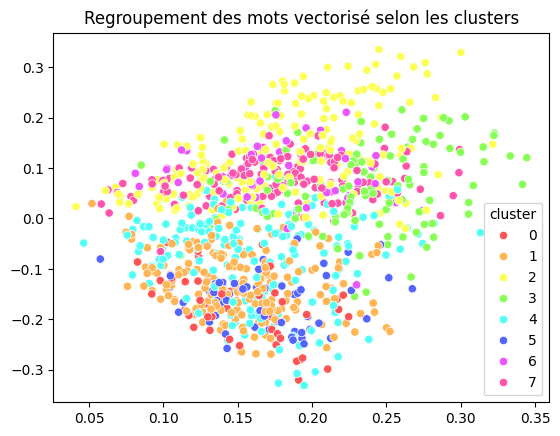

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

nb_dim = 2
trunc = TruncatedSVD(n_components=nb_dim)
X_2d = trunc.fit_transform(X)

x = [line[0] for line in X_2d]
y = [line[1] for line in X_2d]

print(f"SHAPE AFTER TRANSFORME: {X_2d.shape}")
sns.scatterplot(x=x, y=y, hue=df_clean["cluster"], palette=palette)
plt.title("Regroupement des mots vectorisé selon les clusters")

In [91]:
words_frequences = []

for num_cluster, lst in clusters_frequent_words.items():
    freq_words = {}
    for word, freq in lst:
        freq_words[word] = freq
    words_frequences.append(freq_words)

words_frequences

[{'elbow': 13, 'wrist': 10, 'forearm': 10, 'feels': 9, 'palm': 9},
 {'makes': 6, 'ache': 5, 'knee': 5, 'deep': 4, 'ankle': 4},
 {'cough': 9, 'throat': 7, 'felt': 6, 'cold': 5, 'nose': 5},
 {'pain': 16, 'ear': 13, 'head': 7, 'feel': 7, 'throbbing': 5},
 {'itchy': 8, 'hot': 7, 'red': 7, 'skin': 7, 'rash': 6},
 {'shoulder': 18, 'reaching': 11, 'makes': 7, 'gives': 7, 'arm': 6},
 {'pressure': 29,
  'blood pressure': 13,
  'blood': 11,
  'chest': 9,
  'pressure chest': 8},
 {'feel': 10, 've': 8, 'doctor': 6, 'notice': 5, 'headaches': 4}]

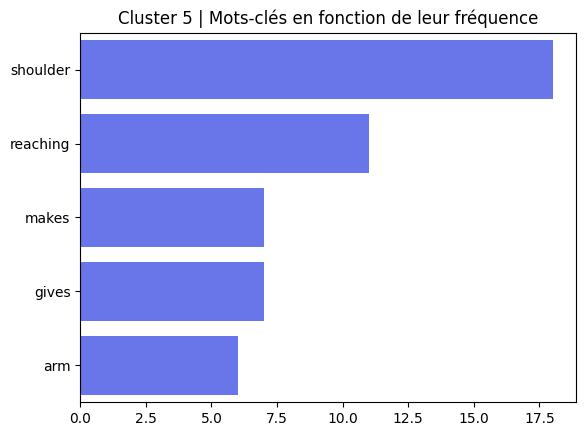

In [84]:
import matplotlib.pyplot as plt

clust_ind = 5

sns.barplot(x=words_frequences[clust_ind].values(), y=words_frequences[clust_ind].keys(), color=palette[clust_ind])
plt.title(f"Cluster {clust_ind} | Mots-clés en fonction de leur fréquence")
plt.show()